In [11]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# load dataset
df = pd.read_excel("School data.xlsx")
print("data load successfull",df)

data load successfull      School_ID    District     Block Urban_Rural  %_Math_Score  \
0        SCH_1  District_C  Block_C1       Rural         43.32   
1        SCH_2  District_A  Block_A3       Rural         81.98   
2        SCH_3  District_B  Block_B1       Rural         44.68   
3        SCH_4  District_A  Block_A1       Urban         44.86   
4        SCH_5  District_C  Block_C1       Rural         47.41   
...        ...         ...       ...         ...           ...   
5195  SCH_5196  District_A  Block_A3       Rural           NaN   
5196  SCH_5197  District_A  Block_A1       Urban         64.93   
5197  SCH_5198  District_B  Block_B1       Rural         67.46   
5198  SCH_5199  District_C  Block_C2       Urban         58.35   
5199  SCH_5200  District_C  Block_C2       Urban         38.73   

      %_Language_Score  %_Science_Score  Teacher_Student_Ratio  \
0                48.87            48.89                   40.1   
1                83.18            83.26              

In [14]:
#step1 Data Understanding
df.head()

,School_ID,District,Block,Urban_Rural,%_Math_Score,%_Language_Score,%_Science_Score,Teacher_Student_Ratio,Avg_Teacher_Experience_Years,Teacher_Trainings_Attended,Electricity_Available,Internet_Available,Functional_Toilets,Library_Available,%_Marginalized_Students,%_Students_With_Home_Internet,Parent_Literacy_Rate
0,SCH_1,District_C,Block_C1,Rural,43.32,48.87,48.89,40.1,5.7,1,1,0.0,1,0,29.7,5.7,33.9
1,SCH_2,District_A,Block_A3,Rural,81.98,83.18,83.26,NaN,5.8,1,1,0.0,0,0,36.1,4.0,40.6
2,SCH_3,District_B,Block_B1,Rural,44.68,46.38,40.19,29.9,7.1,2,1,1.0,0,0,38.9,17.4,47.6
3,SCH_4,District_A,Block_A1,Urban,44.86,35.20,47.77,24.6,2.6,1,1,1.0,0,0,11.2,35.8,73.3
4,SCH_5,District_C,Block_C1,Rural,47.41,47.94,50.99,39.8,6.1,1,1,0.0,1,0,33.1,13.6,35.3


In [15]:
df.shape

(5200, 17)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   School_ID                      5200 non-null   object 
 1   District                       5200 non-null   object 
 2   Block                          5200 non-null   object 
 3   Urban_Rural                    5200 non-null   object 
 4   %_Math_Score                   4942 non-null   float64
 5   %_Language_Score               5200 non-null   float64
 6   %_Science_Score                5200 non-null   float64
 7   Teacher_Student_Ratio          4940 non-null   float64
 8   Avg_Teacher_Experience_Years   5200 non-null   float64
 9   Teacher_Trainings_Attended     5200 non-null   int64  
 10  Electricity_Available          5200 non-null   int64  
 11  Internet_Available             4940 non-null   float64
 12  Functional_Toilets             5200 non-null   i

In [17]:
df.describe()

,%_Math_Score,%_Language_Score,%_Science_Score,Teacher_Student_Ratio,Avg_Teacher_Experience_Years,Teacher_Trainings_Attended,Electricity_Available,Internet_Available,Functional_Toilets,Library_Available,%_Marginalized_Students,%_Students_With_Home_Internet,Parent_Literacy_Rate
count,4942.000000,5200.000000,5200.000000,4940.000000,5200.000000,5200.000000,5200.000000,4940.000000,5200.000000,5200.000000,5200.000000,5200.000000,4941.000000
mean,60.055898,62.970896,61.338762,29.980951,8.096596,1.995385,0.895577,0.295344,0.954423,0.483462,30.401288,16.770077,49.776644
std,15.106160,16.569802,18.025438,9.957824,3.916906,1.430434,0.305838,0.456243,0.208586,0.499774,11.916650,12.773571,16.936643
min,0.326857,1.380000,1.510000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-5.000000
25%,49.582500,51.520000,48.890000,23.100000,5.400000,1.000000,1.000000,0.000000,1.000000,0.000000,22.300000,6.200000,38.400000
50%,59.850000,63.030000,61.150000,29.800000,8.000000,2.000000,1.000000,0.000000,1.000000,0.000000,31.000000,15.200000,49.500000
75%,70.630000,74.452500,73.950000,36.600000,10.800000,3.000000,1.000000,1.000000,1.000000,1.000000,38.800000,25.300000,60.800000
max,107.344878,100.000000,100.000000,100.000000,22.700000,9.000000,1.000000,1.000000,1.000000,1.000000,73.100000,66.000000,150.000000


In [18]:
#Step2 Data Cleaning
# Check missing values
df.isnull().sum()

School_ID                          0
District                           0
Block                              0
Urban_Rural                        0
%_Math_Score                     258
%_Language_Score                   0
%_Science_Score                    0
Teacher_Student_Ratio            260
Avg_Teacher_Experience_Years       0
Teacher_Trainings_Attended         0
Electricity_Available              0
Internet_Available               260
Functional_Toilets                 0
Library_Available                  0
%_Marginalized_Students            0
%_Students_With_Home_Internet      0
Parent_Literacy_Rate             259
dtype: int64

In [20]:
#Handle missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

In [21]:
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\Shree\AppData\Local\Temp\ipykernel_10196\3991344066.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [26]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
print("\nAfter Cleaning Shape:", df.shape)


After Cleaning Shape: (5200, 17)


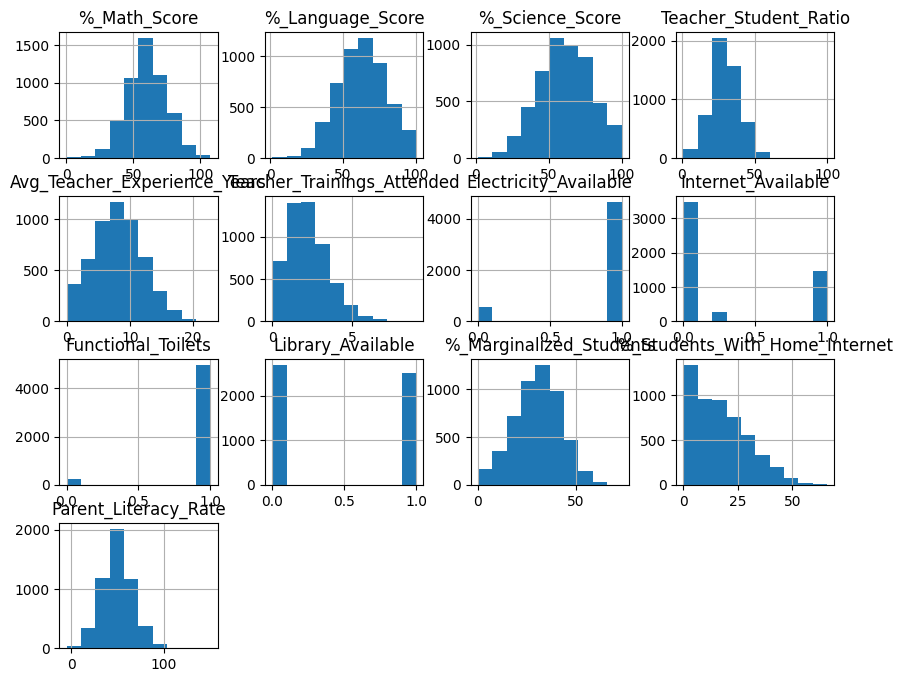

In [27]:
#step3 EDA(Exploratory Data Analysis)  
#1 Univariate Analysis
#Histogram
df.hist(figsize=(10,8))
plt.show()

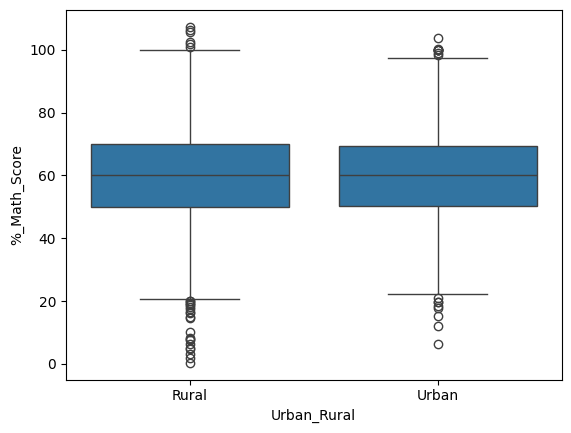

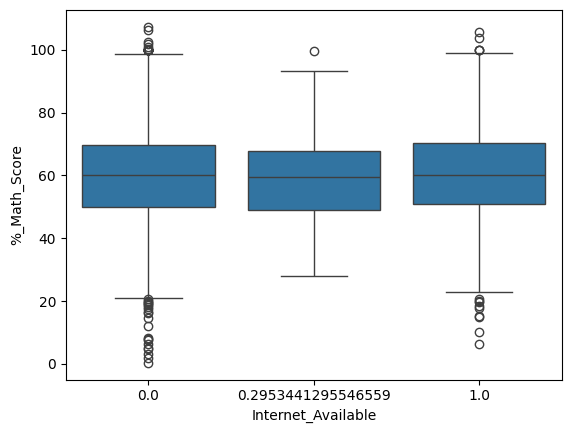

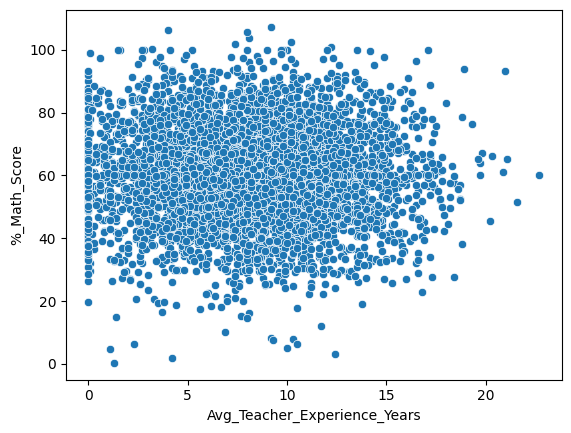

In [32]:
#2 Bivariate Analysis
#Urban vs Rural
sns.boxplot(x='Urban_Rural', y='%_Math_Score', data=df)
plt.show()
#Infrastructure vs Score
sns.boxplot(x='Internet_Available', y='%_Math_Score', data=df)
plt.show()
#Teacher Experience vs Math Score
sns.scatterplot(x='Avg_Teacher_Experience_Years', y='%_Math_Score', data=df)
plt.show()


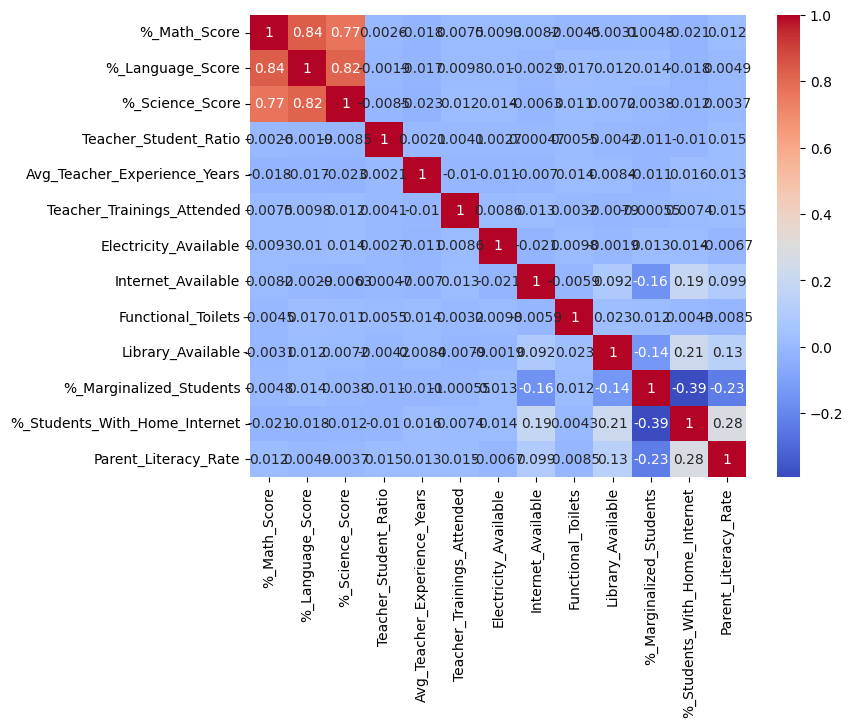

In [33]:
#3 Correlation Analysis
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [36]:
#Step4 Insights  
print("_____Insights_____")
print("1. Parent Literacy Rate has a strong positive impact on student performance.")
print("   Schools with higher parent literacy show better student scores.")
print("2. Internet availability improves student performance.")
print("   Schools with internet access generally have higher scores.")
print("3. Teacher experience positively affects results.")
print("   More experienced teachers are associated with better student outcomes.")
print("4. Urban schools perform better than rural schools.")
print("   This may be due to better infrastructure and resources.")
print("5. Higher percentage of marginalized students slightly lowers performance.")
print("   Socio-economic factors influence student achievement.")

_____Insights_____
1. Parent Literacy Rate has a strong positive impact on student performance.
   Schools with higher parent literacy show better student scores.
2. Internet availability improves student performance.
   Schools with internet access generally have higher scores.
3. Teacher experience positively affects results.
   More experienced teachers are associated with better student outcomes.
4. Urban schools perform better than rural schools.
   This may be due to better infrastructure and resources.
5. Higher percentage of marginalized students slightly lowers performance.
   Socio-economic factors influence student achievement.


In [55]:
#Step 5 Simple Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df.drop(['%_Math_Score','%_Science_Score', '%_Language_Score'], axis=1)
y = df['%_Math_Score']
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = LinearRegression()
model.fit(X_train, y_train)
print("Model Accuracy:", model.score(X_test, y_test))

Model Accuracy: 0.8284241111025619
